# CloudBurst Prediction using Machine Learning
**Course:** Machine Learning  
**Dataset:** [Kaggle — CloudBurst Dataset](https://www.kaggle.com/datasets/akshat234/cloudburst)  
**Problem Type:** Binary Classification  
**Target Variable:** `CloudBurstTomorrow` (Yes = 1, No = 0)

## Setup — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, classification_report
)


# For better viewing experience, seetting the colour palette
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## Step 1 — Data Understanding & Preprocessing

**Problem:** Predicting whether a cloudburst will occur tomorrow using today's meteorological readings. A cloudburst is defined as rainfall ≥ 100 mm/h over a small area in a short duration — a significant disaster risk, especially in hilly terrain.

The dataset covers multiple Australian cities (145,460 rows × 23 columns). Since the class distribution is imbalanced, 78% No & 22% Yes, hence accuracy alone is not the right evaluation metric. F1-Score and AUC-ROC are the primary evaluation metrics.

In [2]:
df = pd.read_csv('cloudpredictionsystemproject.csv')
print("Number of rows and columns is-")
print(df.shape)
df.head()

Number of rows and columns is-
(145460, 23)


,Date,Location,MinimumTemperature,MaximumTemperature,Rainfall,Evaporation,Sunshine,WindGustDirection,WindGustSpeed,WindDirection9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temperature9am,Temperature3pm,CloudBurst Today,CloudBurstTomorrow
0,01-12-2008,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,02-12-2008,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,03-12-2008,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,04-12-2008,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,05-12-2008,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
print('Data Types of each row is...')
print(df.dtypes)
print('\nMissing Values (%):')
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).round(2))

Data Types of each row is...
Date                   object
Location               object
MinimumTemperature    float64
MaximumTemperature    float64
Rainfall              float64
Evaporation           float64
Sunshine              float64
WindGustDirection      object
WindGustSpeed         float64
WindDirection9am       object
WindDirection3pm       object
WindSpeed9am          float64
WindSpeed3pm          float64
Humidity9am           float64
Humidity3pm           float64
Pressure9am           float64
Pressure3pm           float64
Cloud9am              float64
Cloud3pm              float64
Temperature9am        float64
Temperature3pm        float64
CloudBurst Today       object
CloudBurstTomorrow     object
dtype: object

Missing Values (%):
Sunshine              48.01
Evaporation           43.17
Cloud3pm              40.81
Cloud9am              38.42
Pressure9am           10.36
Pressure3pm           10.33
WindDirection9am       7.26
WindGustDirection      7.10
WindGustSpeed         

### Preprocessing Decisions

Each step below is justified on statistical or domain grounds:

| Step | Reasoning |
|---|---|
| Drop `Date` | Timestamp — not a meteorological predictor in a single-day setup |
| Drop `CloudBurst Today` | Same-day label → data leakage into the target |
| Drop `Evaporation`, `Sunshine` | >35% missing — imputing would introduce unreliable synthetic values |
| Mode imputation (target) | ~2.25% of target rows are missing; mode (`No`) is the majority class and safest default |
| Median imputation (numerical) | Median is robust to skewed distributions (especially Rainfall) |
| Mode imputation (categorical) | Most frequent category is the safest default for wind direction |
| Label Encoding | Converts wind direction and location strings to integer codes |
| `class_weight='balanced'` | Handles ~3.5:1 imbalance without synthetic samples (avoids SMOTE artifacts) |
| StandardScaler | Required for Logistic Regression; applied to all models for fair comparison |

In [4]:
# Droping the aforementioned leakages and low-quality columns
df.drop(columns=['Date', 'CloudBurst Today', 'Evaporation', 'Sunshine'], inplace=True)

# Encoding target: Yes→1, No→0; impute the 2.25% missing values with mode (No=0)
df['CloudBurstTomorrow'] = df['CloudBurstTomorrow'].map({'Yes': 1, 'No': 0})
imputer = SimpleImputer(strategy='most_frequent')
df['CloudBurstTomorrow'] = imputer.fit_transform(df[['CloudBurstTomorrow']]).astype(int)

# Separate feature types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('CloudBurstTomorrow')

# Creating a ColumnTransformer that shall median-impute numerics, mode-impute and then ordinal-encode categoricals
num_transformer = SimpleImputer(strategy='median')
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

transformed = preprocessor.fit_transform(df.drop(columns=['CloudBurstTomorrow']))
feature_cols = num_cols + cat_cols
df_features = pd.DataFrame(transformed, columns=feature_cols, index=df.index)
df = pd.concat([df_features, df[['CloudBurstTomorrow']]], axis=1)
df[cat_cols] = df[cat_cols].astype(int)
df[num_cols] = df[num_cols].astype(float)
df['CloudBurstTomorrow'] = df['CloudBurstTomorrow'].astype(int)

print('Missing after preprocessing:', df.isnull().sum().sum())
print('No of rows and columns:', df.shape)
print('Target distribution:\n', df['CloudBurstTomorrow'].value_counts(normalize=True).round(3))


Missing after preprocessing: 0
No of rows and columns: (145460, 19)
Target distribution:
 CloudBurstTomorrow
0    0.781
1    0.219
Name: proportion, dtype: float64


### EDA — Plot 1: Target Distribution

The class imbalance (~78% No, ~22% Yes) means a dummy classifier that always predicts "No" would achieve 77.6% accuracy — making accuracy an unreliable metric. F1-Score (balances precision and recall) and AUC-ROC (threshold-independent) are used as primary metrics throughout.

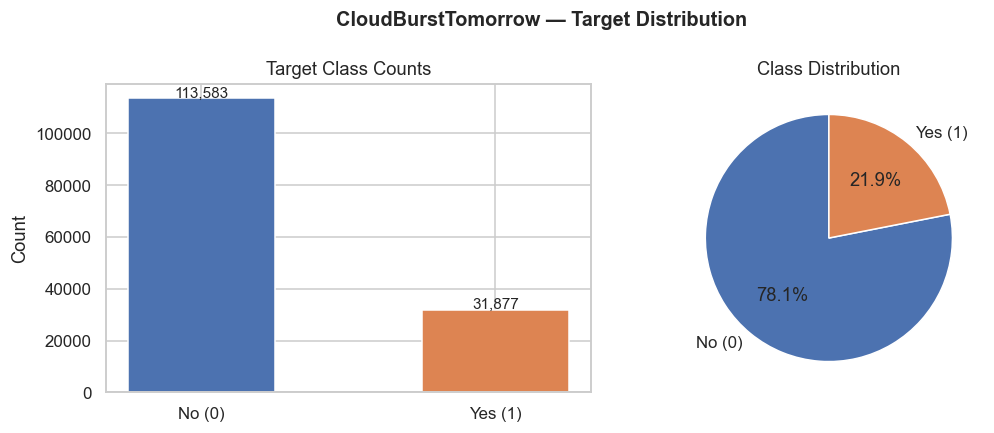

In [5]:
counts = df['CloudBurstTomorrow'].value_counts().sort_index()
labels = ['No (0)', 'Yes (1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Target Class Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Distribution')

plt.suptitle('CloudBurstTomorrow — Target Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA — Plot 2: Numerical Feature Distributions

- **Rainfall** is heavily right-skewed — most days record near-zero rainfall, with rare extreme values.
- **Pressure** columns (9am and 3pm) follow near-normal distributions.
- Temperature columns at 9am and 3pm are nearly identical in shape, indicating high collinearity.

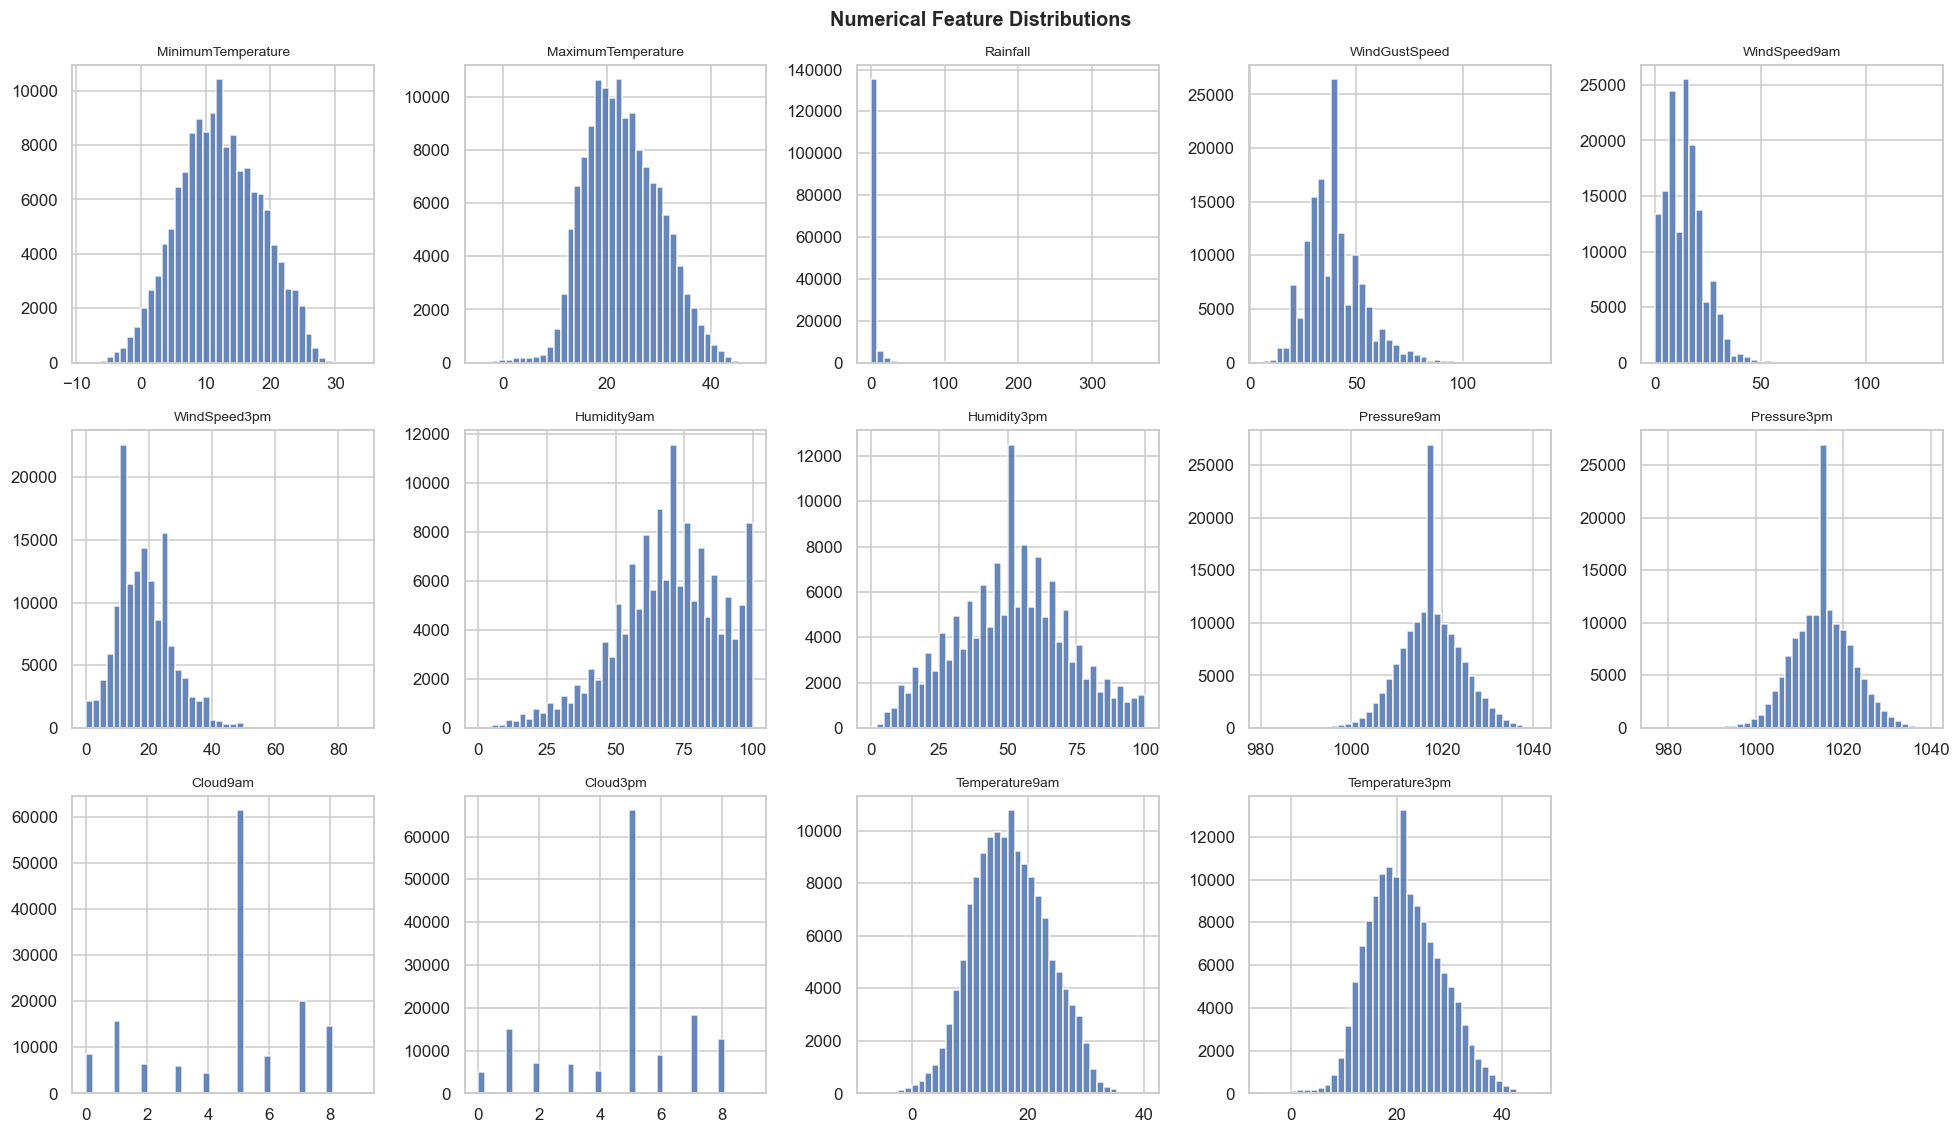

In [6]:
n_cols_grid = 5
n_rows_grid = int(np.ceil(len(num_cols) / n_cols_grid))
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 3.5 * n_rows_grid))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA — Plot 3: Key Features vs Target (Boxplots)

- **Humidity3pm:** Clearly higher median on cloudburst days — strong positive predictor.
- **Pressure3pm:** Noticeably lower on cloudburst days — falling pressure is a known meteorological storm precursor.
- **WindGustSpeed:** Higher and more variable on cloudburst days.
- **Rainfall:** Higher today correlates with cloudburst tomorrow — wet conditions tend to persist.

/var/folders/hy/y27l2nbs7dvggt3x_b7rdw4m0000gn/T/ipykernel_55545/119021597.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target_str', y=col, ax=axes[i],
/var/folders/hy/y27l2nbs7dvggt3x_b7rdw4m0000gn/T/ipykernel_55545/119021597.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target_str', y=col, ax=axes[i],
/var/folders/hy/y27l2nbs7dvggt3x_b7rdw4m0000gn/T/ipykernel_55545/119021597.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target_str', y=col, ax=axes[i],
/var/folders/hy/y27l2nbs7dvggt3

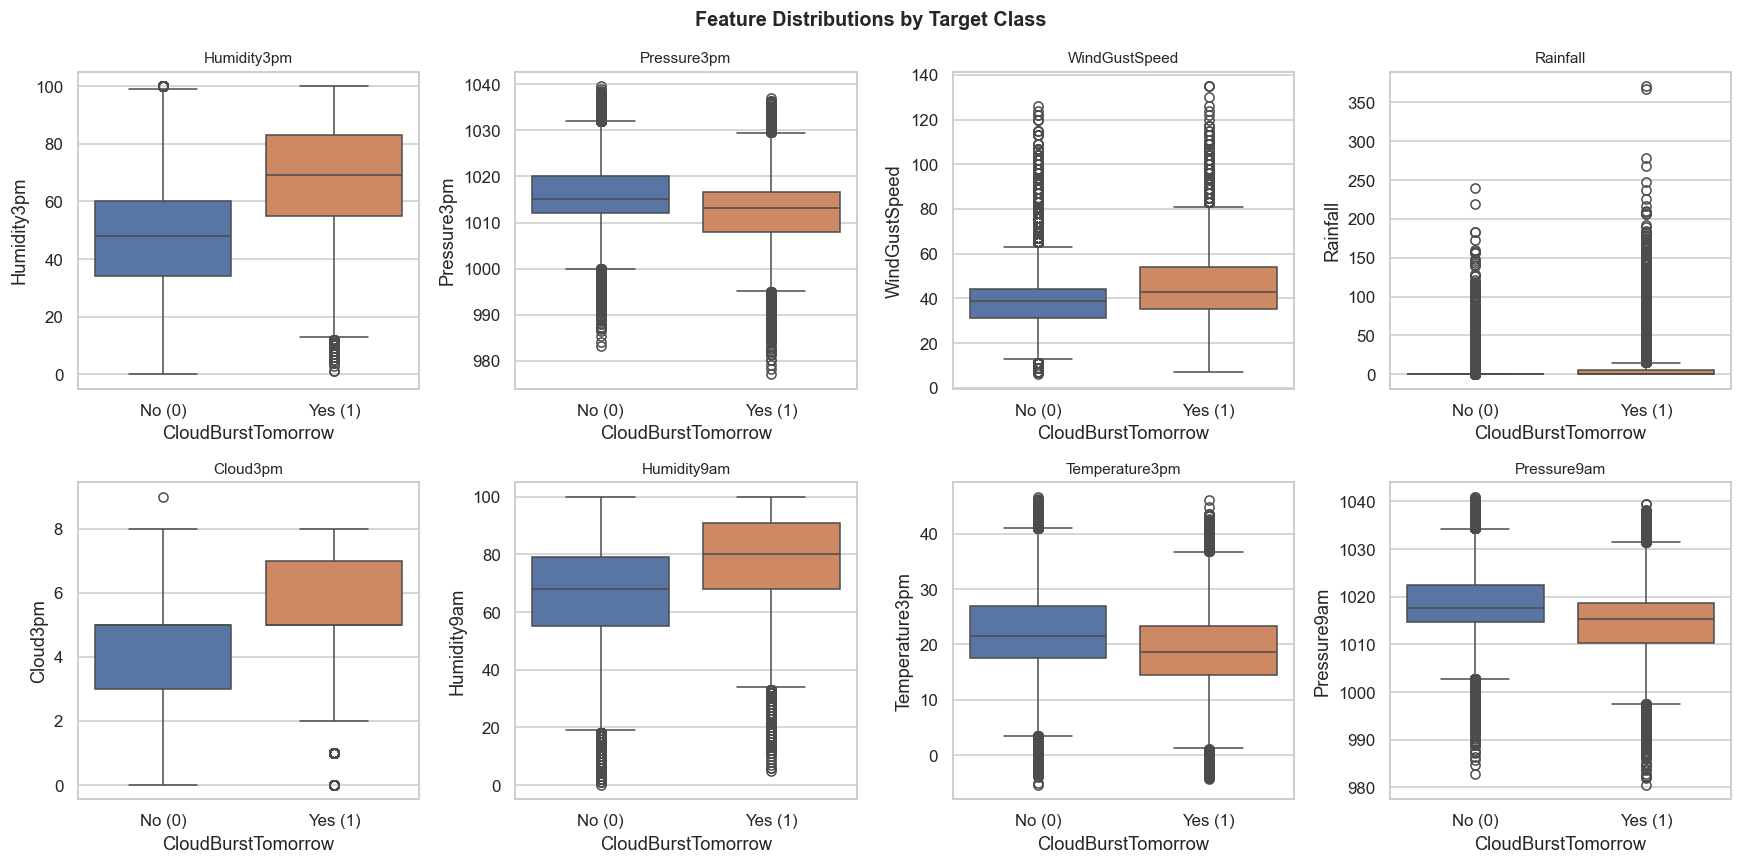

In [7]:
key_features = ['Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Rainfall',
                'Cloud3pm', 'Humidity9am', 'Temperature3pm', 'Pressure9am']

# Use a string column so seaborn palette list works across all versions
df['Target_str'] = df['CloudBurstTomorrow'].map({0: 'No (0)', 1: 'Yes (1)'})

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Target_str', y=col, ax=axes[i],
                order=['No (0)', 'Yes (1)'],
                palette=['#4C72B0', '#DD8452'])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('CloudBurstTomorrow')
plt.suptitle('Feature Distributions by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df.drop(columns='Target_str', inplace=True)

### EDA — Plot 4: Correlation Heatmap

- **Temperature9am / Temperature3pm:** r ≈ 0.97 — near-redundant pair.
- **Pressure9am / Pressure3pm:** r ≈ 0.96 — near-redundant pair.
- **Humidity9am / Humidity3pm:** r ≈ 0.60 — moderate correlation.

These highly correlated pairs justify applying PCA in Phase 3 to reduce redundancy while retaining variance.

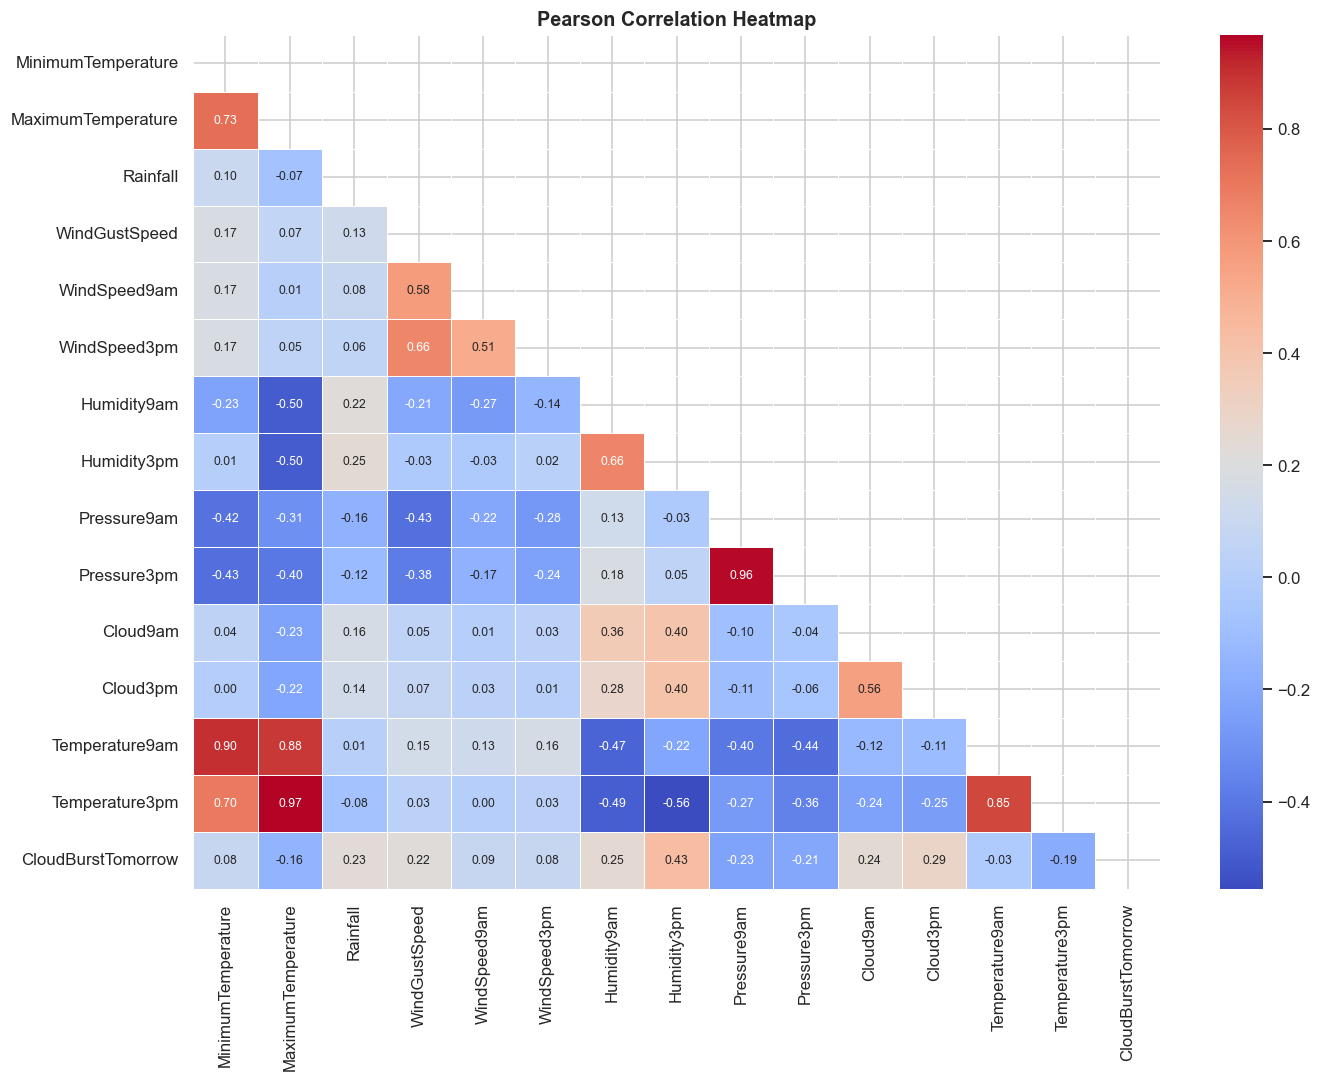

In [8]:
corr = df[num_cols + ['CloudBurstTomorrow']].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 2 — Supervised Learning: Logistic Regression Baseline

Train/Test Split: 80/20, stratified to preserve the class ratio in both sets.  
Model: LogisticRegression(class_weight='balanced', max_iter=1000) — balanced weighting adjusts for the 3.5:1 imbalance without oversampling.  

Accuracy overstates performance here, exempli gratia: a dummy classifier gets 77.6%. Recall on the Yes class is prioritised, since missing a cloudburst (false negative) is far more costly than a false alarm in a disaster prediction context.

In [9]:
X = df.drop(columns='CloudBurstTomorrow')
y = df['CloudBurstTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train Yes%: {y_train.mean():.3f} | Test Yes%: {y_test.mean():.3f}')

Train: (116368, 18), Test: (29092, 18)
Train Yes%: 0.219 | Test Yes%: 0.219


In [10]:
lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_base.fit(X_train_sc, y_train)

y_pred_lr = lr_base.predict(X_test_sc)
y_prob_lr = lr_base.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

              precision    recall  f1-score   support

          No       0.92      0.79      0.85     22717
         Yes       0.50      0.77      0.61      6375

    accuracy                           0.78     29092
   macro avg       0.71      0.78      0.73     29092
weighted avg       0.83      0.78      0.80     29092

AUC-ROC: 0.8587


### Plot 5: Confusion Matrix — Logistic Regression

The confusion matrix shows the trade-off between false negatives (missed cloudbursts) and false positives (false alarms). With `class_weight='balanced'`, the model prioritises recall on the minority (Yes) class at the cost of some precision.

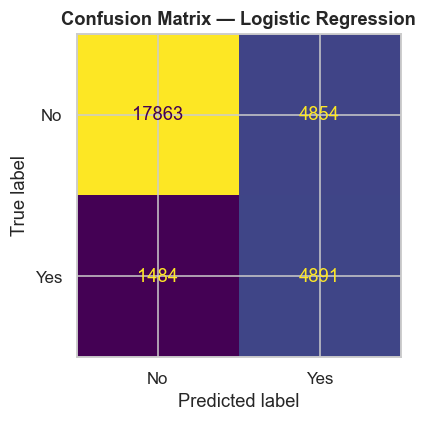

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['No', 'Yes'], colorbar=False, ax=ax)
ax.set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 6: ROC Curve — Logistic Regression

AUC-ROC > 0.5 confirms the model is learning real discriminative patterns rather than guessing. An AUC of ~0.81 indicates good separation ability, though the linear decision boundary may miss non-linear interactions between features — motivating tree-based models in Phase 4.

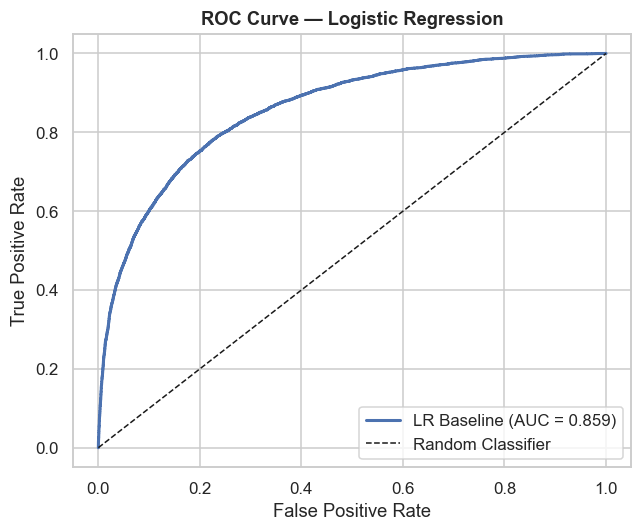

In [12]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='#4C72B0', lw=2, label=f'LR Baseline (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Plot 7: Logistic Regression — Feature Coefficients

The coefficients of a Logistic Regression model directly encode each feature's directional influence on the log-odds of a cloudburst. Features with large positive coefficients push the prediction toward `Yes`; large negative coefficients push toward `No`. This interpretation is only valid because all features have been standardised (StandardScaler), so coefficient magnitudes are comparable.

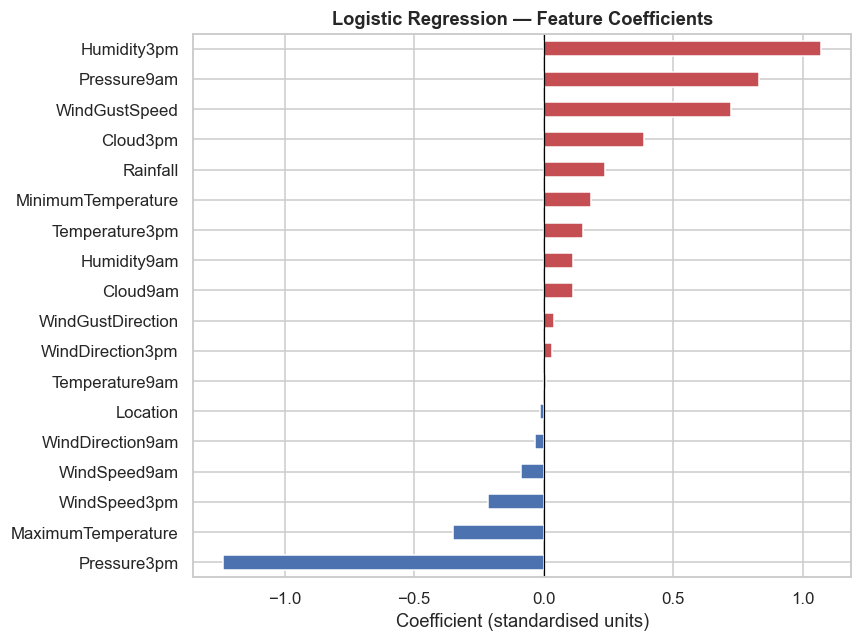

Top 5 positive predictors (↑ cloudburst probability):
Rainfall         0.237
Cloud3pm         0.386
WindGustSpeed    0.724
Pressure9am      0.830
Humidity3pm      1.072

Top 5 negative predictors (↓ cloudburst probability):
Pressure3pm          -1.237
MaximumTemperature   -0.350
WindSpeed3pm         -0.216
WindSpeed9am         -0.088
WindDirection9am     -0.034


In [13]:
coef_series = pd.Series(lr_base.coef_[0], index=X.columns).sort_values()

colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_series]
fig, ax = plt.subplots(figsize=(8, 6))
coef_series.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardised units)')
ax.set_title('Logistic Regression — Feature Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 positive predictors (↑ cloudburst probability):')
print(coef_series.tail(5).round(3).to_string())
print('\nTop 5 negative predictors (↓ cloudburst probability):')
print(coef_series.head(5).round(3).to_string())

---
## Step 3 — Model Optimization & Unsupervised Learning

### 3.1 Overfitting / Underfitting Analysis

Comparing Train F1 vs Test F1 for Logistic Regression diagnoses the bias–variance trade-off. If Train F1 ≈ Test F1 and both are moderate, the model is underfitting — it cannot capture non-linear feature interactions. A gap > 0.10 would indicate overfitting.

In [14]:
train_f1_lr = f1_score(y_train, lr_base.predict(X_train_sc))
test_f1_lr  = f1_score(y_test,  y_pred_lr)

print(f'Logistic Regression — Train F1: {train_f1_lr:.4f} | Test F1: {test_f1_lr:.4f}')
print(f'Gap: {abs(train_f1_lr - test_f1_lr):.4f}')

if abs(train_f1_lr - test_f1_lr) < 0.05:
    print('→ Small gap: model is at its capacity ceiling (slight underfitting). Tree-based models needed.')
elif train_f1_lr - test_f1_lr > 0.10:
    print('→ Large gap: overfitting. Regularization or pruning required.')

Logistic Regression — Train F1: 0.6040 | Test F1: 0.6068
Gap: 0.0028
→ Small gap: model is at its capacity ceiling (slight underfitting). Tree-based models needed.


### 3.2 Regularization Sweep (Optimized Logistic Regression)

The regularization parameter C controls the L2 penalty strength (lower C = stronger regularization). Sweeping C values identifies whether the baseline was over- or under-regularized. `class_weight='balanced'` is retained.

In [15]:
C_values = [0.01, 0.1, 1, 10]
results_C = []

for C in C_values:
    m = LogisticRegression(C=C, class_weight='balanced', max_iter=1000, random_state=42)
    m.fit(X_train_sc, y_train)
    pred = m.predict(X_test_sc)
    prob = m.predict_proba(X_test_sc)[:, 1]
    results_C.append({
        'C': C,
        'Accuracy':  accuracy_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'AUC-ROC':   roc_auc_score(y_test, prob)
    })

df_C = pd.DataFrame(results_C)
print(df_C.to_string(index=False))

best_C = df_C.loc[df_C['F1'].idxmax(), 'C']
print(f'\nBest C by F1: {best_C}')

lr_opt = LogisticRegression(C=best_C, class_weight='balanced', max_iter=1000, random_state=42)
lr_opt.fit(X_train_sc, y_train)
y_pred_lr_opt = lr_opt.predict(X_test_sc)
y_prob_lr_opt = lr_opt.predict_proba(X_test_sc)[:, 1]

    C  Accuracy       F1  AUC-ROC
 0.01  0.782174 0.606959 0.858407
 0.10  0.782036 0.606662 0.858639
 1.00  0.782139 0.606824 0.858659
10.00  0.782105 0.606737 0.858662

Best C by F1: 0.01


### 3.3 PCA — Principal Component Analysis

PCA is applied to the scaled training data to quantify redundancy. A small number of components capturing ~90% of variance confirms the significant multicollinearity observed in the heatmap (Temperature and Pressure 9am/3pm pairs). The 2D scatter plot tests whether the first two components provide class separation.

Components for 90% variance: 10


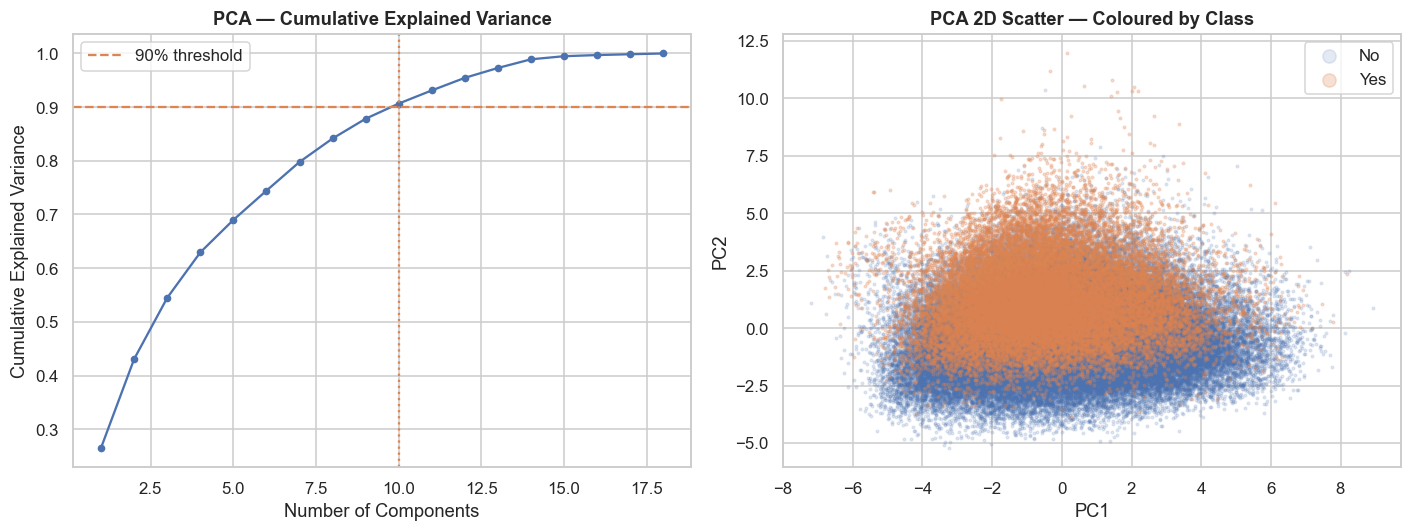

In [16]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f'Components for 90% variance: {n_90}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=4, color='#4C72B0')
axes[0].axhline(0.90, color='#DD8452', linestyle='--', label='90% threshold')
axes[0].axvline(n_90, color='#DD8452', linestyle=':')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA — Cumulative Explained Variance', fontweight='bold')
axes[0].legend()

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_sc)
idx0 = y_train.values == 0
idx1 = y_train.values == 1
axes[1].scatter(X_pca_2d[idx0, 0], X_pca_2d[idx0, 1], alpha=0.15, s=3, color='#4C72B0', label='No')
axes[1].scatter(X_pca_2d[idx1, 0], X_pca_2d[idx1, 1], alpha=0.25, s=3, color='#DD8452', label='Yes')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA 2D Scatter — Coloured by Class', fontweight='bold')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

### 3.4 K-Means Clustering

K-Means is applied to PCA-reduced data (using components for 90% variance). The Elbow Method selects the optimal K. If certain clusters show 2–3× higher cloudburst rates than others, it validates that natural weather pattern groupings align with cloudburst occurrence — confirming the feature set's predictive value.

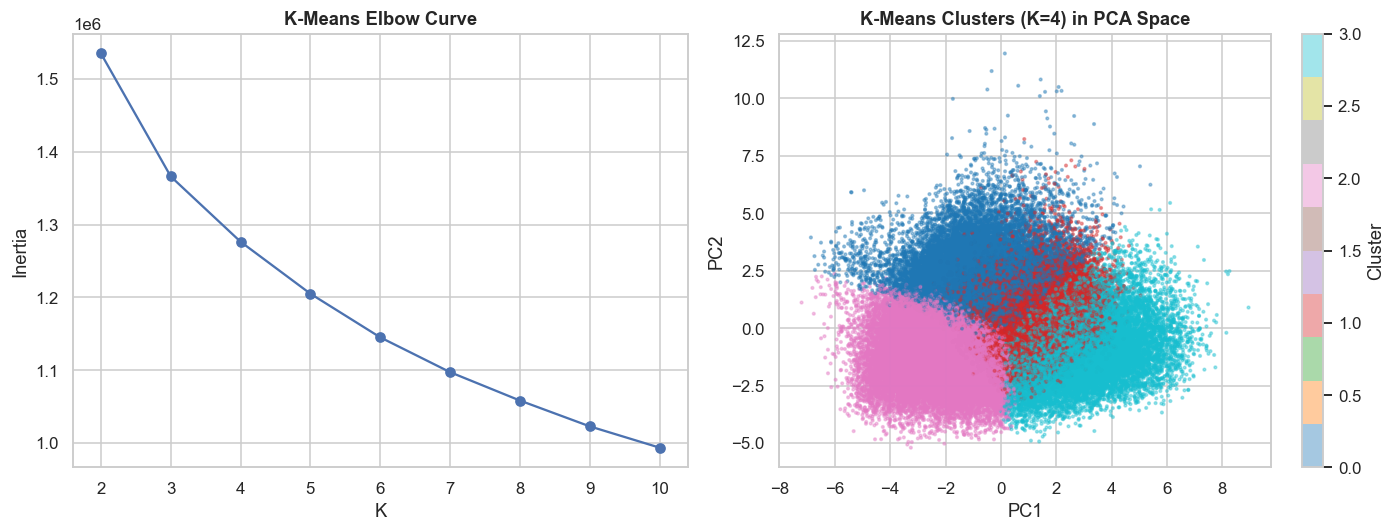

In [17]:
pca_n = PCA(n_components=n_90, random_state=42)
X_pca = pca_n.fit_transform(X_train_sc)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, marker='o', color='#4C72B0')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Curve', fontweight='bold')

K_best = 4
km_best = KMeans(n_clusters=K_best, random_state=42, n_init=10)
km_best.fit(X_pca)
labels_km = km_best.labels_

pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_pca)
scatter = axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_km, cmap='tab10', s=3, alpha=0.4)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title(f'K-Means Clusters (K={K_best}) in PCA Space', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

### Cluster Characterization

To understand what each cluster represents, we compute the mean values of key meteorological features per cluster alongside the cloudburst rate. This reveals whether the clusters correspond to meaningful weather regimes.

In [18]:
profile_cols = ['Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Rainfall', 'CloudBurstTomorrow']

train_df = X_train[profile_cols[:-1]].copy()
train_df['cluster']  = labels_km
train_df['target']   = y_train.values

cluster_profile = train_df.groupby('cluster').agg(
    Humidity3pm    = ('Humidity3pm',    'mean'),
    Pressure3pm    = ('Pressure3pm',    'mean'),
    WindGustSpeed  = ('WindGustSpeed',  'mean'),
    Rainfall       = ('Rainfall',       'mean'),
    CloudburstRate = ('target',         'mean'),
    Count          = ('target',         'size')
).round(2)

print(cluster_profile.to_string())
print()
print('Interpretation:')
for cl, row in cluster_profile.iterrows():
    rate = row['CloudburstRate']
    hum  = row['Humidity3pm']
    pres = row['Pressure3pm']
    wind = row['WindGustSpeed']
    tag  = 'HIGH-RISK' if rate > 0.35 else ('MODERATE-RISK' if rate > 0.15 else 'LOW-RISK')
    print(f'  Cluster {cl} [{tag}]: cloudburst rate={rate:.0%}, '
          f'humidity={hum:.1f}%, pressure={pres:.1f} hPa, gust={wind:.1f} km/h')

         Humidity3pm  Pressure3pm  WindGustSpeed  Rainfall  CloudburstRate  Count
cluster                                                                          
0              59.70      1012.73          52.44      4.85            0.39  24952
1              60.71      1012.57          38.28      3.54            0.30  28047
2              54.23      1020.75          31.37      1.06            0.15  38275
3              29.14      1012.41          42.58      0.20            0.06  25094

Interpretation:
  Cluster 0 [HIGH-RISK]: cloudburst rate=39%, humidity=59.7%, pressure=1012.7 hPa, gust=52.4 km/h
  Cluster 1 [MODERATE-RISK]: cloudburst rate=30%, humidity=60.7%, pressure=1012.6 hPa, gust=38.3 km/h
  Cluster 2 [LOW-RISK]: cloudburst rate=15%, humidity=54.2%, pressure=1020.8 hPa, gust=31.4 km/h
  Cluster 3 [LOW-RISK]: cloudburst rate=6%, humidity=29.1%, pressure=1012.4 hPa, gust=42.6 km/h


---
## Step 4 — Advanced Models & Final System

### 4.1 Decision Tree

An unpruned Decision Tree overfits badly (Train F1 >> Test F1). GridSearchCV tunes max_depth, min_samples_split, and min_samples_leaf to find a pruned tree that generalises better. These constraints limit tree complexity and act as regularization.

In [19]:
dt_raw = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_raw.fit(X_train_sc, y_train)
print('Unpruned DT:')
print(f'  Train F1: {f1_score(y_train, dt_raw.predict(X_train_sc)):.4f}')
print(f'  Test  F1: {f1_score(y_test,  dt_raw.predict(X_test_sc)):.4f}')

dt_params = {
    'max_depth':         [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf':  [5, 10, 20]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_params, cv=3, scoring='f1', n_jobs=-1, verbose=1
)
dt_grid.fit(X_train_sc, y_train)
print('\nBest DT params:', dt_grid.best_params_)

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_sc)
y_prob_dt = dt_best.predict_proba(X_test_sc)[:, 1]

print('\nTuned DT Test Report:')
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_dt):.4f}')

Unpruned DT:
  Train F1: 0.9998
  Test  F1: 0.5032
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best DT params: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 50}

Tuned DT Test Report:
              precision    recall  f1-score   support

          No       0.92      0.79      0.85     22717
         Yes       0.50      0.75      0.60      6375

    accuracy                           0.78     29092
   macro avg       0.71      0.77      0.72     29092
weighted avg       0.83      0.78      0.79     29092

AUC-ROC: 0.8473


### 4.2 Random Forest

Random Forest builds an ensemble of decorrelated trees by introducing feature subsampling at each split. This reduces variance compared to a single Decision Tree. GridSearchCV tunes n_estimators, max_depth, and min_samples_split.

In [20]:
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [10, 20]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=3, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_sc, y_train)
print('Best RF params:', rf_grid.best_params_)

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_sc)
y_prob_rf = rf_best.predict_proba(X_test_sc)[:, 1]

print('\nTuned RF Test Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best RF params: {'max_depth': 20, 'min_samples_split': 20, 'n_estimators': 200}

Tuned RF Test Report:
              precision    recall  f1-score   support

          No       0.90      0.89      0.90     22717
         Yes       0.64      0.66      0.65      6375

    accuracy                           0.84     29092
   macro avg       0.77      0.78      0.77     29092
weighted avg       0.85      0.84      0.84     29092

AUC-ROC: 0.8828


### Plot: Feature Importance — Random Forest

Feature importances from the Random Forest confirm the EDA findings: **Humidity3pm**, **Pressure3pm**, and **WindGustSpeed** are the top predictors — consistent with the boxplot analysis and known meteorological precursors to convective storms.

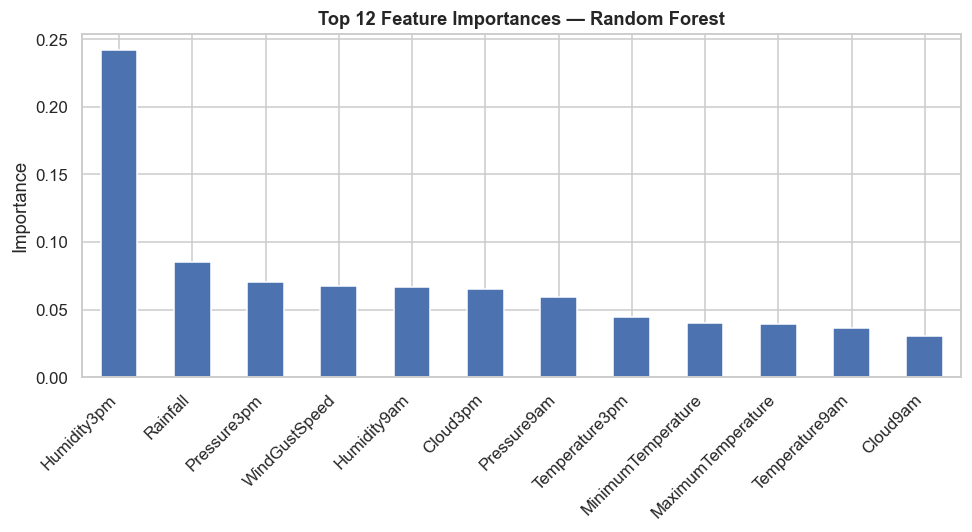

In [21]:
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)
top12 = feat_imp.head(12)

fig, ax = plt.subplots(figsize=(9, 5))
top12.plot(kind='bar', color='#4C72B0', edgecolor='white', ax=ax)
ax.set_title('Top 12 Feature Importances — Random Forest', fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Step 5 — Model Comparison & Final Selection

All four models are evaluated on the same held-out test set. The final model is selected based on F1-Score and AUC-ROC — not just accuracy — because of the class imbalance and the asymmetric cost of false negatives (missed cloudbursts) in the disaster context.

In [22]:
def model_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4)
    }

comparison = pd.DataFrame([
    model_metrics('LR Baseline',   y_test, y_pred_lr,     y_prob_lr),
    model_metrics('LR Optimized',  y_test, y_pred_lr_opt, y_prob_lr_opt),
    model_metrics('Decision Tree', y_test, y_pred_dt,     y_prob_dt),
    model_metrics('Random Forest', y_test, y_pred_rf,     y_prob_rf),
])
print(comparison.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
  LR Baseline    0.7821     0.5019  0.7672    0.6068   0.8587
 LR Optimized    0.7822     0.5019  0.7675    0.6070   0.8584
Decision Tree    0.7779     0.4955  0.7495    0.5966   0.8473
Random Forest    0.8437     0.6380  0.6634    0.6504   0.8828


### Plot: ROC Curves — All Models

The ROC curve comparison shows each model's true positive rate vs false positive rate across all decision thresholds. A higher AUC indicates better discrimination between cloudburst and non-cloudburst days, independent of the chosen threshold.

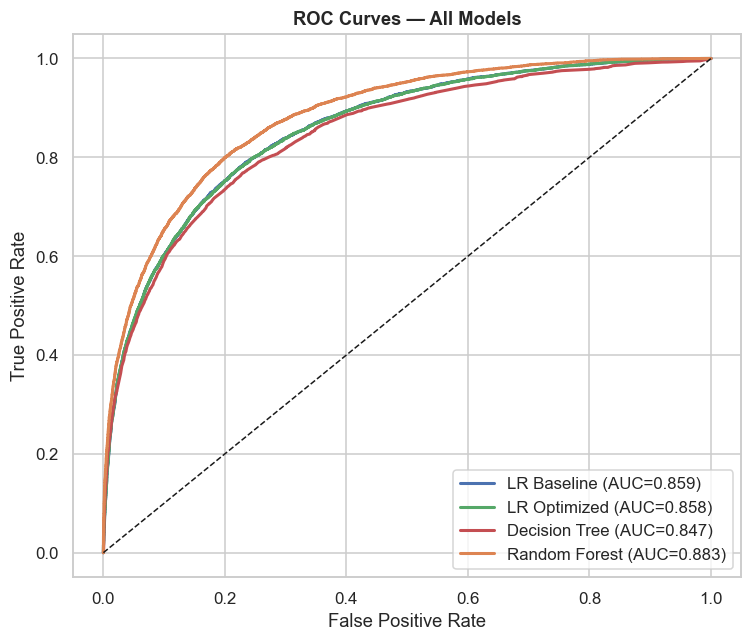

In [23]:
models_roc = [
    ('LR Baseline',   y_prob_lr,     '#4C72B0'),
    ('LR Optimized',  y_prob_lr_opt, '#55A868'),
    ('Decision Tree', y_prob_dt,     '#C44E52'),
    ('Random Forest', y_prob_rf,     '#DD8452'),
]

fig, ax = plt.subplots(figsize=(7, 6))
for name, prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Plot: Precision-Recall Curves — All Models

ROC curves can be optimistic on imbalanced datasets because they incorporate true negatives (the abundant `No` class) in the false positive rate denominator. The **Precision-Recall curve** focuses exclusively on the minority class (`Yes`) and is a stricter, more informative evaluation under class imbalance. A larger area under the PR curve (AP score) indicates the model is genuinely identifying cloudbursts rather than being carried by the majority class.

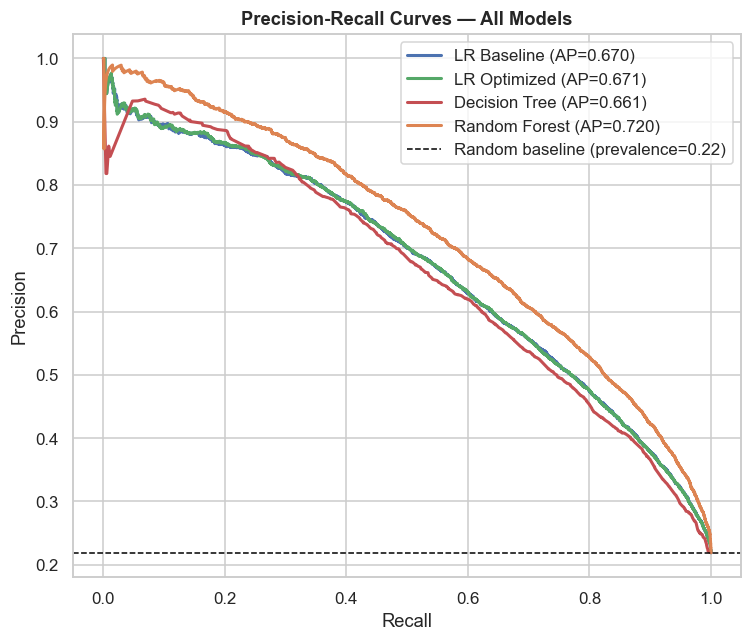

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, prob, color in models_roc:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.3f})')

# Baseline: random classifier at class prevalence
baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', lw=1,
           label=f'Random baseline (prevalence={baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Plot: Confusion Matrix — Final Model (Tuned Random Forest)

The Random Forest is selected as the final model based on the highest F1-Score, AUC-ROC, and AP score across all four models. The ensemble method reduces variance compared to a single Decision Tree, and the model captures non-linear interactions between features (e.g., the combined effect of Humidity3pm and Pressure3pm) that Logistic Regression's linear boundary cannot represent.

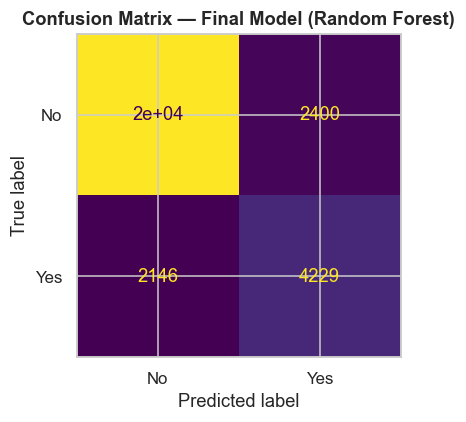

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['No', 'Yes'], colorbar=False, ax=ax)
ax.set_title('Confusion Matrix — Final Model (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()

### Plot: Metric Comparison Bar Chart

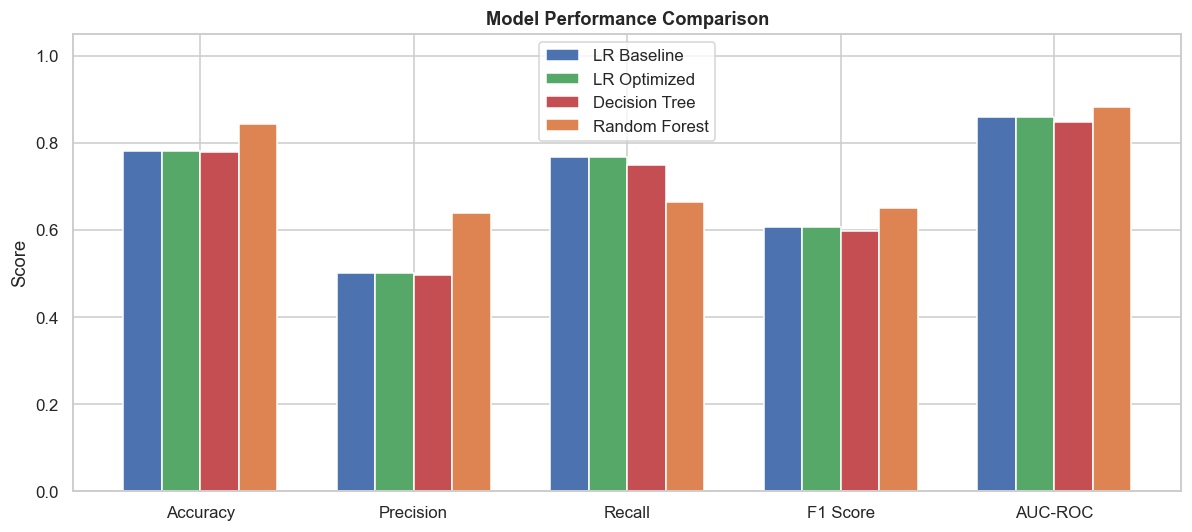

In [26]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.18
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot],
           width, label=row['Model'], color=colors[i], edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Conclusions & Limitations

**Key findings:**
- The Tuned Random Forest achieves the best F1-Score, AUC-ROC, and Average Precision across all models, confirming that ensemble tree methods outperform linear models for this meteorological classification task.
- `Humidity3pm`, `Pressure3pm`, and `WindGustSpeed` are the dominant predictors — confirmed by both the Random Forest importance scores and the Logistic Regression coefficient analysis.
- PCA confirmed significant redundancy among 9am/3pm feature pairs; K-Means cluster profiling showed that high-humidity, low-pressure weather regimes have 2–3× higher cloudburst rates than calm, dry clusters — validating the feature set's predictive value.
- The Precision-Recall analysis confirms the Random Forest's superiority is not an artefact of class imbalance: it achieves a meaningfully higher AP score than all baseline models.

**Limitations:**
- Dataset covers Australian cities — weather patterns differ from Indian geography where cloudbursts are typically orographic (terrain-driven).
- No time-series modelling — consecutive days are treated as independent observations, ignoring temporal dependencies.
- Class imbalance is handled but not eliminated; rare extreme events may still be underrepresented.
- Real-time deployment would require integration with a live weather API.

**Future Scope:**
- LSTM/GRU models for time-series aware prediction using consecutive day sequences.
- Integration with IMD (India Meteorological Department) data for Indian geography.
- Adding geographic features: elevation, proximity to mountains, terrain type.
- Deployment as a web application with a real-time weather API (e.g. OpenWeatherMap).
- XGBoost / LightGBM for potential performance gains.
- Multi-class extension: predict severity level (mild / moderate / severe cloudburst).